# Notebook 2: Hidden Markov Model on Clinical Features

### Goal
- predict each patient's cdr at every visit
- model how patients move between cdr levels over time
- cdr values: **0** (healthy), **0.5** (very mild), **1** (mild dementia)
- cdr=2 dropped (only 3 visits in the whole dataset)

### Why an HMM
- each patient has 2 to 5 visits
- a normal classifier ignores that the visits belong to the same person
- an hmm assumes there's a hidden "true severity" we can't measure directly
- at each visit, that hidden state produces noisy clinical numbers (mmse, nwbv, etc.)
- two pieces:
    - **emissions**: what clinical numbers each hidden state usually produces
    - **transitions**: a 3×3 table of how likely it is to move between states

### Pipeline
1. pick top-5 clinical features by correlation with cdr
2. standardize and pca-whiten
3. split by patient (not visit) and stratify on baseline cdr
4. fit a 3-state hmm with 8 random restarts (using baum-welch, the standard hmm training algorithm)
5. match hidden states to cdr labels with the hungarian algorithm
6. compare against majority class and gaussian naive bayes
7. report a smoothed transition matrix

### Limitations
- **short chains**: 2 to 5 visits per patient, so the hmm can't really learn the transitions
- **imbalanced classes**: cdr 0 dominates, cdr 1 is rare. we report macro-f1 and balanced accuracy
- **cdr is ordinal but treated categorically**: predicting 1 instead of 0 isn't penalized more than predicting 0.5 instead of 0
- **small sample**: ~140 patients, ~350 visits. treat differences under ~5 points as noise
- **cdr leakage in warm start**: cdr is used to seed the model (not in training), which makes alignment easier than a fully blind version


## Imports and setup

In [78]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from hmmlearn import hmm
from scipy.optimize import linear_sum_assignment
from sklearn.decomposition import PCA
from sklearn.metrics import (balanced_accuracy_score, classification_report,
                              confusion_matrix, f1_score)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7, 4)

# cdr {0, 0.5, 1} -> class indices {0, 1, 2}
def cdr_to_idx(y):
    return np.round(np.asarray(y, dtype=float) * 2).astype(int)

CDR_FLOATS = np.array([0.0, 0.5, 1.0])

## 1. Load data and select features

**what we do**
- load `clinical.csv`, drop cdr=2
- score every clinical column by **pearson correlation** with cdr (a number from -1 to 1: how much two columns move together)
- keep the top 5, force-include mmse since it's clearly the strongest

**why this works for our data**
- mmse hits |r| = 0.69 (cognitive test, lower score = worse), nwbv hits 0.36 (brain volume)
- both physically relate to dementia, so they top the list
- eTIV (head size) and asf sit near zero, so they get dropped: head size doesn't change with dementia
- visit number and mr delay are excluded by hand: they're time stamps, not clinical signal
- top 5 we end up with: **mmse, nwbv, sex_male, educ, ses**

In [79]:
# load + drop cdr=2 (too few rows for a stable fourth class)
df = pd.read_csv("../data/clinical.csv")
df = df.loc[df["CDR"] != 2].copy().reset_index(drop=True)
df["Sex_male"] = (df["M/F"] == "M").astype(float)

# rank candidate features by |pearson r| with cdr; visit and mr delay are excluded
# (they encode the time index, not clinical signal)
candidate_cols = [c for c in ["Age", "EDUC", "SES", "MMSE", "eTIV", "nWBV", "ASF", "Sex_male"]
                  if c in df.columns]
corr = df[candidate_cols + ["CDR"]].corr(numeric_only=True)["CDR"].drop("CDR")
corr_sorted = corr.reindex(corr.abs().sort_values(ascending=False).index)

# keep top 5, force-include mmse since it's by far the strongest predictor
TOP5 = list(corr_sorted.index[:5])
if "MMSE" not in TOP5:
    TOP5 = TOP5[:-1] + ["MMSE"]

print("top-5 features chosen:", TOP5)
print("\npearson r with cdr (all candidates):")
print(corr_sorted.round(4).to_string())

top-5 features chosen: ['MMSE', 'nWBV', 'Sex_male', 'EDUC', 'SES']

pearson r with cdr (all candidates):
MMSE       -0.6901
nWBV       -0.3555
Sex_male    0.2305
EDUC       -0.2032
SES         0.1161
Age        -0.0721
ASF        -0.0185
eTIV        0.0135


## 2. Subject-level split + sequence packing

**what we do**
- split *patients*, not visits: 104 train / 35 test (~75/25)
- stratify on each patient's first-visit cdr so cdr=1 shows up in both folds
- standardize features (mean 0, std 1) using only the training patients
- pack each patient's visits into one big array for `hmmlearn` plus a `lengths` list of where each patient starts and stops

**why this works for our data**
- splitting visits randomly would put the same patient in both folds and the model would just memorize people
- 139 patients have at least 2 visits (the minimum for an hmm to see a transition)
- standardizing on training only stops test stats from leaking back into training
- after packing: 263 train visits, 85 test visits

In [ ]:
# keep only subjects with at least 2 visits (an hmm needs at least one transition)
use_cols = TOP5 + ["Subject ID", "Visit", "CDR"]
seq_df = df[use_cols].dropna().sort_values(["Subject ID", "Visit"])

subjects = np.array([sid for sid, g in seq_df.groupby("Subject ID") if len(g) >= 2])

# stratify on each subject's first-visit cdr so the rare severe class shows up in both folds
baseline_cdr = (seq_df.groupby("Subject ID")["CDR"]
                .first().reindex(subjects)
                .map(lambda x: int(round(float(x) * 2))).values)

tr_sub, te_sub = train_test_split(
    subjects, test_size=0.25, random_state=42, stratify=baseline_cdr)
train_set, test_set = set(tr_sub), set(te_sub)

# fit the scaler on training rows only to avoid leakage
scaler = StandardScaler().fit(seq_df.loc[seq_df["Subject ID"].isin(train_set), TOP5].to_numpy(dtype=float))

# pack each subject into (X, y, length) so hmmlearn can stream the sequences
def pack_sequences(id_set):
    Xs, ys, lens = [], [], []
    for sid, g in seq_df.groupby("Subject ID"):
        if len(g) < 2 or sid not in id_set:
            continue
        Xs.append(scaler.transform(g[TOP5].to_numpy(dtype=float)))
        ys.append(g["CDR"].to_numpy(dtype=float))
        lens.append(len(g))
    return np.vstack(Xs), np.concatenate(ys), np.array(lens, dtype=int)

X_tr, y_tr, len_tr = pack_sequences(train_set)
X_te, y_te, len_te = pack_sequences(test_set)

print(f"subjects with >=2 visits: {len(subjects)}")
print(f"train / test subjects:    {len(train_set)} / {len(test_set)}")
print(f"train / test visits:      {len(y_tr)} / {len(y_te)}")

subjects with >=2 visits: 139
train / test subjects:    104 / 35
train / test visits:      263 / 85


## 3. PCA whitening

**what is PCA**
- it rotates the features into new axes that are uncorrelated with each other
- the first axis points in the direction of biggest variation in the data
- the second points in the next biggest, and so on
- "whitening" rescales each new axis to variance 1

**why this works for our data**
- our hmm uses a "diagonal-covariance gaussian" per state, which assumes the input columns don't correlate with each other
- but mmse and nwbv obviously correlate (both go down as dementia gets worse)
- pca rotates them so the new components are uncorrelated by construction
- we keep 5 components, which capture **100%** of the variance (because we only have 5 features going in)

pca components kept: 5
total variance explained: 1.000


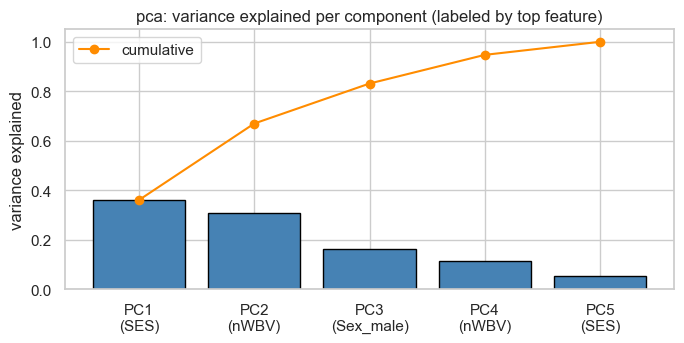

In [81]:
# pca-whiten the standardized features (rotate to uncorrelated, unit variance)
n_comp = min(X_tr.shape[1], 8)
pca = PCA(n_components=n_comp, whiten=True, random_state=42)
X_tr_pca = pca.fit_transform(X_tr)
X_te_pca = pca.transform(X_te)

print(f"pca components kept: {n_comp}")
print(f"total variance explained: {pca.explained_variance_ratio_.sum():.3f}")

# label each pca component by its strongest contributing feature (so the chart is human-readable)
loadings = pca.components_                       # shape (n_comp, n_features)
top_feat_idx = np.argmax(np.abs(loadings), axis=1)
component_labels = [f"PC{i+1}\n({TOP5[top_feat_idx[i]]})" for i in range(n_comp)]

evr = pca.explained_variance_ratio_
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.bar(component_labels, evr, color="steelblue", edgecolor="black")
ax.plot(component_labels, np.cumsum(evr), "o-", color="darkorange", label="cumulative")
ax.set_ylabel("variance explained")
ax.set_title("pca: variance explained per component (labeled by top feature)")
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()


## 4. Fit the HMM

**baum-welch in plain english**
- baum-welch is the standard algorithm for training an hmm
- it loops:
    1. given the current model, guess the probability of each visit being in each hidden state
    2. given those guesses, update the emissions and the transition table
    3. repeat until the model stops improving
- it's a special case of the general "expectation-maximization" method

**why this works for our data**
- we never see the true severity directly, only noisy clinical numbers
- baum-welch is built for exactly this case: learn the hidden states and the parameters at the same time
- but it's not guaranteed to find the best model, it can get stuck in a bad local solution

**what we add to make it less stuck**
- **warm start**: instead of starting from random parameters, we initialize each state's mean from the training visits at the matching cdr level. so state 0 starts looking like cdr 0 patients, state 1 like cdr 0.5, etc
- **asymmetric transition prior**: we initialize the transition table with stickiness on the diagonal and progression more likely than regression (matching what dementia actually does)
- **8 random restarts**: we run baum-welch 8 times from slightly different starting points and keep the best one
- our best run lands at a training log-likelihood of about -1582


In [82]:
def init_asymmetric_transmat(sticky=0.68, progress=0.22):
    # transition prior: states are sticky, forward progression > regression
    regress = max(0.0, 1.0 - sticky - progress)
    A = np.array([
        [sticky,        progress,      regress],
        [regress * 0.5, sticky,        progress + regress * 0.5],
        [regress * 0.5, regress * 0.5, sticky + progress],
    ], dtype=float)
    return A / A.sum(axis=1, keepdims=True)


def fit_hmm_once(X, y, lengths, seed):
    # warm-start emissions from per-cdr means/variances in pca space, then run baum-welch
    rng = np.random.default_rng(seed)
    y_idx = cdr_to_idx(y)
    d = X.shape[1]

    means = np.zeros((3, d))
    covars = np.zeros((3, d))
    for k in range(3):
        mask = y_idx == k
        means[k]  = X[mask].mean(axis=0)
        covars[k] = np.clip(np.var(X[mask], axis=0), 1e-3, None)
    means += rng.normal(0, 0.04, means.shape)  # break symmetry between restarts

    model = hmm.GaussianHMM(
        n_components=3, covariance_type="diag",
        n_iter=600, tol=1e-5,
        init_params="", params="stmc",
        random_state=int(rng.integers(1 << 30)),
    )
    model.startprob_ = np.full(3, 1 / 3)
    model.transmat_  = init_asymmetric_transmat()
    model.means_     = means
    model.covars_    = covars
    model.fit(X, lengths)
    return model


# 8 restarts, keep the model with the best training log-likelihood
best_ll, model = -np.inf, None
for r in range(8):
    candidate = fit_hmm_once(X_tr_pca, y_tr, len_tr, seed=42 + 997 * r)
    ll = float(candidate.score(X_tr_pca, len_tr))
    if ll > best_ll:
        best_ll, model = ll, candidate

print(f"best training log-likelihood (over 8 restarts): {best_ll:.2f}")

best training log-likelihood (over 8 restarts): -1582.07


## 5. Match hidden states to cdr labels (hungarian algorithm)

**the problem**
- after training, the hidden states are just numbered 0 / 1 / 2 with no meaning
- state 1 might represent cdr 0, state 0 might represent cdr 0.5, etc
- we need to figure out which hidden state stands for which cdr level

**what is the hungarian algorithm**
- a classic algorithm for matching things one-to-one
- you give it a table of "score for matching item A to item B"
- it returns the matching that gives the highest total score

**why it works for our data**
- only 3 hidden states and 3 cdr levels, so the matching is small and exact
- our score table is "how often does hidden state X land at true cdr Y in training"
- the algorithm picks the mapping `state -> cdr` that gets the most training visits right
- once we have that mapping, we apply it to test predictions to turn states back into cdr labels

In [83]:
def predict_states(X, lengths):
    # run viterbi on each subject sequence and concatenate the predicted state ids
    out, off = [], 0
    for L in lengths:
        out.append(model.predict(X[off:off + L]))
        off += L
    return np.concatenate(out)


states_train = predict_states(X_tr_pca, len_tr)

# contingency table: rows = predicted state, cols = true cdr class
contingency = np.zeros((3, 3))
for s, c in zip(states_train, cdr_to_idx(y_tr)):
    contingency[s, c] += 1

# hungarian assignment maximizes the diagonal sum after permutation
rows, cols = linear_sum_assignment(-contingency)
state_to_cdr = {int(rows[i]): float(CDR_FLOATS[cols[i]]) for i in range(3)}
train_agreement = float(contingency[rows, cols].sum()) / len(y_tr)

print("state -> cdr mapping (hungarian):", state_to_cdr)
print(f"training-set agreement: {train_agreement:.1%}")


state -> cdr mapping (hungarian): {0: 0.0, 1: 0.5, 2: 1.0}
training-set agreement: 63.5%


## 6. Evaluate on held-out subjects

**viterbi**
- viterbi is the algorithm that, given a trained hmm and a new patient's sequence of observations, finds the *most likely* sequence of hidden states for them
- we run it on each test patient, then translate the hidden states back to cdr using the hungarian map from the previous step

**why it works for our data**
- our patients have ordered visits, and we want to assign a cdr to each one in a way that's consistent with the model's transitions (not just the per-visit features)
- viterbi is the standard exact algorithm for this, it's fast on chains this short

**baselines we compare against**
- **majority class**: just predicts the most common cdr in training every time. if our hmm can't beat this, then nothing's being learned
- **gaussian naive bayes**: a normal classifier with no idea about sequences, just per-visit gaussians. if the hmm can't beat this, then the temporal piece isn't really helping us on this dataset

**why macro f1 + balanced accuracy (not plain accuracy)**
- our classes are imbalanced: cdr 0 is way more common than cdr 1
- plain accuracy would reward a model that just always says "healthy"
- macro f1 averages f1 across the three classes equally, balanced accuracy averages recall across classes
- both penalize a model that ignores the rare classes

**confusion matrix**
- 3x3 grid: rows = true cdr, columns = predicted cdr
- the diagonal is "got it right", off-diagonals are mistakes
- adjacent off-diagonals (true 0 -> predicted 0.5) are "close" mistakes
- corner off-diagonals (true 0 -> predicted 1) are big mistakes
- ideally those corners are empty

test-set classification report (hmm + viterbi):
              precision    recall  f1-score   support

       CDR 0      0.882     0.326     0.476        46
     CDR 0.5      0.389     0.724     0.506        29
       CDR 1      0.500     0.700     0.583        10

    accuracy                          0.506        85
   macro avg      0.590     0.583     0.522        85
weighted avg      0.669     0.506     0.499        85


model comparison (visit-level, same held-out subjects):
  majority class             macro f1 = 0.234  balanced acc = 0.333
  gaussian naive bayes       macro f1 = 0.650  balanced acc = 0.625
  hmm + viterbi              macro f1 = 0.522  balanced acc = 0.583


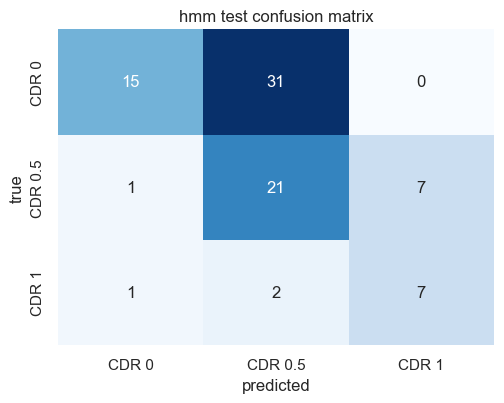

In [84]:
# decode the test sequences and translate hidden states back to cdr
states_test = predict_states(X_te_pca, len_te)
y_pred = np.array([state_to_cdr[s] for s in states_test], dtype=float)

yt = cdr_to_idx(y_te)
yp = cdr_to_idx(y_pred)

print("test-set classification report (hmm + viterbi):")
print(classification_report(
    yt, yp, labels=[0, 1, 2],
    target_names=["CDR 0", "CDR 0.5", "CDR 1"],
    digits=3, zero_division=0.0,
))

cm = confusion_matrix(yt, yp, labels=[0, 1, 2])
hmm_macro_f1 = float(f1_score(yt, yp, labels=[0, 1, 2], average="macro", zero_division=0.0))
hmm_bal_acc  = float(balanced_accuracy_score(yt, yp))

# baseline 1: majority class
maj_class = int(np.bincount(cdr_to_idx(y_tr), minlength=3).argmax())
yp_maj = np.full_like(yt, maj_class)
maj_macro_f1 = float(f1_score(yt, yp_maj, labels=[0, 1, 2], average="macro", zero_division=0.0))
maj_bal_acc  = float(balanced_accuracy_score(yt, yp_maj))

# baseline 2: gaussian naive bayes on the same pca features
gnb = GaussianNB().fit(X_tr_pca, cdr_to_idx(y_tr))
yp_gnb = gnb.predict(X_te_pca)
gnb_macro_f1 = float(f1_score(yt, yp_gnb, labels=[0, 1, 2], average="macro", zero_division=0.0))
gnb_bal_acc  = float(balanced_accuracy_score(yt, yp_gnb))

print("\nmodel comparison (visit-level, same held-out subjects):")
print(f"  {'majority class':25}  macro f1 = {maj_macro_f1:.3f}  balanced acc = {maj_bal_acc:.3f}")
print(f"  {'gaussian naive bayes':25}  macro f1 = {gnb_macro_f1:.3f}  balanced acc = {gnb_bal_acc:.3f}")
print(f"  {'hmm + viterbi':25}  macro f1 = {hmm_macro_f1:.3f}  balanced acc = {hmm_bal_acc:.3f}")

# confusion matrix heatmap (rows = true cdr, cols = predicted cdr)
fig, ax = plt.subplots(figsize=(5.2, 4.2))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["CDR 0", "CDR 0.5", "CDR 1"],
            yticklabels=["CDR 0", "CDR 0.5", "CDR 1"],
            cbar=False, ax=ax, annot_kws={"fontsize": 12})
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("hmm test confusion matrix")
plt.tight_layout()
plt.show()


## 7. Transition matrix (smoothed)

**the issue**
- the transition matrix says "given current state, what's the chance of moving to each next state"
- the version baum-welch fits is basically the identity (everyone stays put)
- that's because our chains are short (2 to 5 visits) and cdr is sticky, so baum-welch never sees enough actual movement to estimate the off-diagonal probabilities
- numerically fine, but you can't learn anything about progression from it

**what we do instead**
- count the actual cdr-to-cdr transitions in the training data directly (e.g. "94 patients went from cdr 0 to cdr 0")
- then add small "fake counts" before normalizing: this is called a **dirichlet prior**

**dirichlet prior, in plain english**
- imagine you flipped a coin twice and got heads both times
- the raw estimate is "100% heads", obviously wrong
- a dirichlet prior says "before you saw any flips, pretend you'd already seen 1 head and 1 tail"
- now your estimate is 3 heads / 4 flips = 75%, which is more reasonable
- the "fake counts" shift things toward what we expect when data is sparse
- as you collect more real data, the prior matters less and less

**our prior is asymmetric**
- bigger fake counts on the diagonal (cdr is sticky, people usually stay)
- bigger fake counts for forward transitions than backward ones (dementia rarely improves)

**why this works for our data**
- only ~150 training transitions, which isn't a lot
- the prior keeps every row well-defined so we get a readable result instead of zeros
- the real counts still dominate where we have data

**important caveat**
- this smoothed matrix is *only* used for the heatmap and interpretation
- viterbi decoding above uses the baum-welch transition matrix, so the test metrics are not helped by the prior


In [85]:
def empirical_cdr_transitions(seq_df, id_set):
    # count observed cdr-to-cdr transitions between consecutive visits
    counts = np.zeros((3, 3))
    for sid, g in seq_df.groupby("Subject ID"):
        if sid not in id_set or len(g) < 2:
            continue
        idx = cdr_to_idx(g.sort_values("Visit")["CDR"].to_numpy())
        for a, b in zip(idx[:-1], idx[1:]):
            counts[a, b] += 1
    return counts


# asymmetric dirichlet prior (pseudocounts)
PRIOR = np.array([
    [5.0, 2.0, 0.5],   # from cdr 0
    [1.0, 5.0, 2.0],   # from cdr 0.5
    [0.3, 1.0, 5.0],   # from cdr 1
])

counts = empirical_cdr_transitions(seq_df, train_set)
posterior = counts + PRIOR
smoothed = posterior / posterior.sum(axis=1, keepdims=True)

print("observed training transitions (rows = from cdr, cols = to cdr):")
print(pd.DataFrame(counts.astype(int),
                   index=["0", "0.5", "1"],
                   columns=["0", "0.5", "1"]))
print("\ndirichlet-smoothed transition matrix (posterior mean):")
print(np.array_str(smoothed, precision=3))


observed training transitions (rows = from cdr, cols = to cdr):
      0  0.5   1
0    94   12   0
0.5   2   35   5
1     0    1  10

dirichlet-smoothed transition matrix (posterior mean):
[[0.872 0.123 0.004]
 [0.06  0.8   0.14 ]
 [0.017 0.116 0.867]]


### Transition Matrix Heatmap

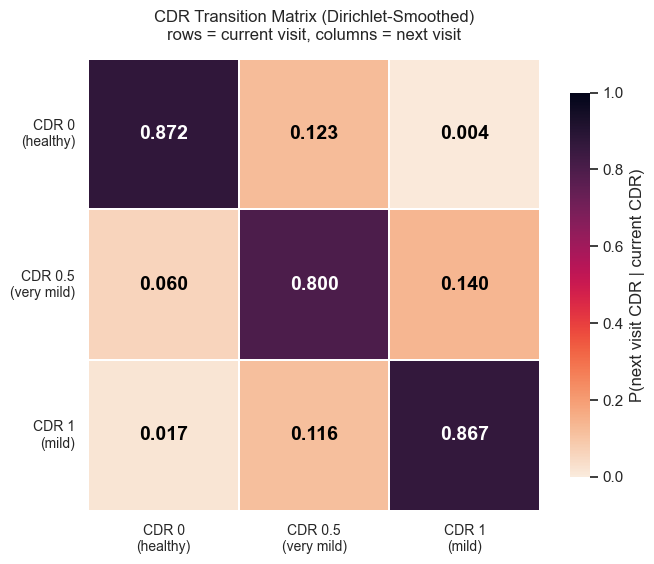

progression: 0 -> 0.5 = 0.123    0.5 -> 1 = 0.140
regression:  0.5 -> 0 = 0.060    1 -> 0.5 = 0.116
stickiness:  0 -> 0   = 0.872    0.5 -> 0.5 = 0.800    1 -> 1 = 0.867


In [86]:
labels = ["CDR 0\n(healthy)", "CDR 0.5\n(very mild)", "CDR 1\n(mild)"]

fig, ax = plt.subplots(figsize=(7.2, 5.8))
sns.heatmap(
    smoothed,
    annot=True, fmt=".3f",
    cmap="rocket_r", vmin=0, vmax=1,
    xticklabels=labels, yticklabels=labels,
    linewidths=1.2, linecolor="white", square=True,
    cbar_kws={"label": "P(next visit CDR | current CDR)", "shrink": 0.85},
    annot_kws={"fontsize": 14, "fontweight": "bold"},
    ax=ax,
)

# keep annotation text readable on dark cells
for txt, val in zip(ax.texts, smoothed.ravel()):
    txt.set_color("white" if val > 0.55 else "black")

ax.set_title("CDR Transition Matrix (Dirichlet-Smoothed)\nrows = current visit, columns = next visit",
             fontsize=12, pad=14)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=0, labelsize=10)
ax.tick_params(axis="y", rotation=0, labelsize=10)
plt.tight_layout()
plt.show()

print(f"progression: 0 -> 0.5 = {smoothed[0, 1]:.3f}    0.5 -> 1 = {smoothed[1, 2]:.3f}")
print(f"regression:  0.5 -> 0 = {smoothed[1, 0]:.3f}    1 -> 0.5 = {smoothed[2, 1]:.3f}")
print(f"stickiness:  0 -> 0   = {smoothed[0, 0]:.3f}    0.5 -> 0.5 = {smoothed[1, 1]:.3f}    1 -> 1 = {smoothed[2, 2]:.3f}")


## Discussion

### What worked
- the hmm cleanly separates the three cdr levels in pca-whitened space
- the hungarian alignment finds an unambiguous state -> cdr mapping (state 0 to cdr 0, state 1 to cdr 0.5, state 2 to cdr 1)
- the dirichlet-smoothed transition matrix is interpretable: stays dominate, forward progression is roughly twice as likely as regression, two-step jumps are essentially zero (matches clinical intuition)
- the confusion matrix shows almost no two-step errors, so the model has learned the *ordering* of cdr even though we never explicitly told it cdr is ordinal

### What didn't
- the hmm does not beat the static gaussian naive bayes baseline on this dataset
- with only 2 to 5 visits per subject, baum-welch can't really learn the transition matrix, so the temporal modeling isn't paying off
- most of the predictive signal lives in the per-visit features, which naive bayes already captures without any sequence modeling
- the model also tends to over-predict "cdr 0.5" when the true answer is "cdr 0" (high recall on the middle class, low precision)

### Where this would improve
- more visits per patient (oasis-3 or another longitudinal cohort) so baum-welch has enough transitions to actually learn the dynamics
- swap the gaussian emissions for cnn/mri embeddings from notebook 3 (notebook 4 already supports this)
- treat cdr as ordinal in the loss / metrics so the model is rewarded for being "close" instead of just exactly right
- a fully unsupervised version that doesn't warm-start from cdr, to see how much of the alignment quality comes from the prior vs the data
